# Proyecto 2 – Clasificador de barcos con CNN desde cero


In [1]:
# ===============================
# LIBRERÍAS
# ===============================

import os
import time
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tqdm import tqdm
from google.colab import drive, files

import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU       :", tf.config.list_physical_devices("GPU"))
if not tf.config.list_physical_devices("GPU"):
    print("\n⚠ NO hay GPU activa. Ve a: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU, y reinicia.")

TensorFlow: 2.20.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ===============================
# MONTAJE DE GOOGLE DRIVE
# ===============================

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ===============================
# RUTA DEL DATASET (carpetas ya separadas en train / val / test)
# ===============================
# Estructura esperada en Drive:
#   DataSet_Split/
#     train/  Barcos/  No_Barcos/
#     val/    Barcos/  No_Barcos/
#     test/   Barcos/  No_Barcos/

RUTA_DATASET = "/content/drive/MyDrive/DataSet_Split"
CLASES = ["No_Barcos", "Barcos"]          # índice 0 = No barco | índice 1 = Barco
SPLITS = ["train", "val", "test"]
EXT_VALIDAS = (".png", ".jpg", ".jpeg")

print(f"{'Conjunto':<8} | {'Barcos':<7} | {'No_Barcos':<9}")
for s in SPLITS:
    nb = len([f for f in os.listdir(os.path.join(RUTA_DATASET, s, "Barcos")) if f.lower().endswith(EXT_VALIDAS)])
    nn = len([f for f in os.listdir(os.path.join(RUTA_DATASET, s, "No_Barcos")) if f.lower().endswith(EXT_VALIDAS)])
    print(f"{s:<8} | {nb:<7} | {nn:<9}")

Conjunto | Barcos  | No_Barcos
train    | 753     | 753      
val      | 150     | 150      
test     | 100     | 100      


In [4]:
# ===============================
# PREPROCESAMIENTO: VALIDACIÓN 80x80 (PADDING SOLO SI HACE FALTA)
# ===============================
# Las imágenes ya son 80x80 RGB. Se conserva el color. Si alguna no mide 80x80 se ajusta
# con padding (sin deformar) y se redimensiona.

TAMANO_IMG = 80

def redimensionar_padding(img, size):
    h, w = img.shape[:2]
    max_lado = max(h, w)
    fondo = np.zeros((max_lado, max_lado, 3), dtype=np.uint8)

    x_offset = (max_lado - w) // 2
    y_offset = (max_lado - h) // 2
    fondo[y_offset:y_offset+h, x_offset:x_offset+w] = img

    return cv2.resize(fondo, (size, size), interpolation=cv2.INTER_AREA)

def cargar_imagen(ruta):
    """Devuelve (imagen RGB 80x80 uint8, fue_ajustada) o (None, False) si está corrupta."""
    img = cv2.imread(ruta, cv2.IMREAD_COLOR)          # BGR, descarta canal alfa
    if img is None:
        return None, False
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)        # → RGB
    ajustada = False
    if img.shape[:2] != (TAMANO_IMG, TAMANO_IMG):
        img = redimensionar_padding(img, TAMANO_IMG)
        ajustada = True
    return img, ajustada

Cargado desde cache: /content/drive/MyDrive/DataSet_Split/cache_split.npz


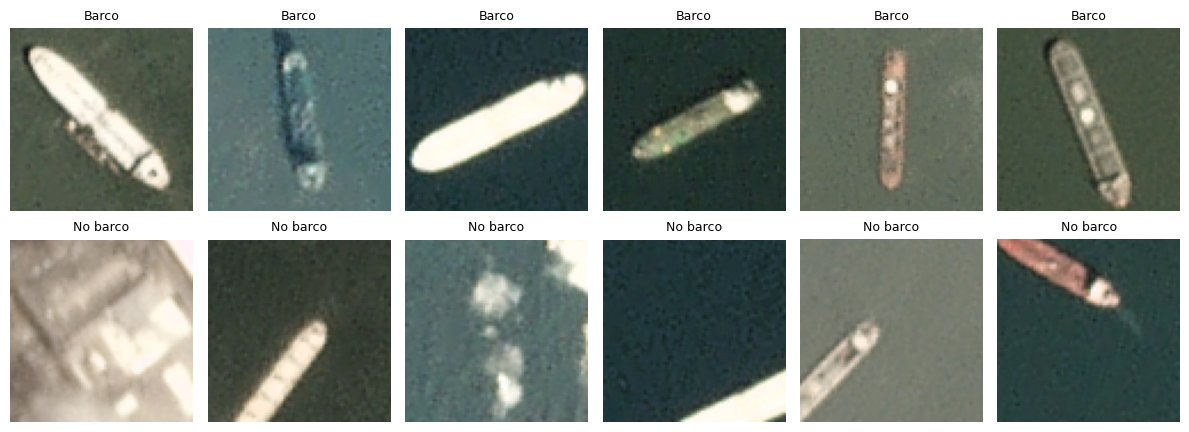

In [5]:
# ===============================
# CREACIÓN DE ARRAYS X, y (UNO POR CONJUNTO)
# ===============================
# Leer imágenes desde Drive es lento. Con USAR_CACHE = True, la primera vez se guarda un .npz
# en Drive y las siguientes se carga en segundos.
# (Si cambias las carpetas, borra el cache o pon USAR_CACHE = False.)

USAR_CACHE = True
RUTA_CACHE = os.path.join(RUTA_DATASET, "cache_split.npz")

def cargar_split(nombre):
    X_, y_ = [], []
    ajustadas, corruptas = 0, 0
    for clase in CLASES:
        etiqueta = 1 if clase == "Barcos" else 0
        ruta_clase = os.path.join(RUTA_DATASET, nombre, clase)
        for archivo in tqdm(sorted(os.listdir(ruta_clase)), desc=f"{nombre}/{clase}"):
            if not archivo.lower().endswith(EXT_VALIDAS):
                continue
            img, ajustada = cargar_imagen(os.path.join(ruta_clase, archivo))
            if img is None:
                corruptas += 1
                continue
            ajustadas += int(ajustada)
            X_.append(img); y_.append(etiqueta)
    print(f"  {nombre}: ajustadas a 80x80 = {ajustadas} | corruptas omitidas = {corruptas}")
    # float32 rango 0-255: el escalado/normalización está DENTRO del modelo
    return np.array(X_, dtype="float32"), np.array(y_)

if USAR_CACHE and os.path.exists(RUTA_CACHE):
    d = np.load(RUTA_CACHE)
    X_train, y_train, X_val, y_val, X_test, y_test = (d[k] for k in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"])
    print("Cargado desde cache:", RUTA_CACHE)
else:
    X_train, y_train = cargar_split("train")
    X_val,   y_val   = cargar_split("val")
    X_test,  y_test  = cargar_split("test")
    if USAR_CACHE:
        np.savez_compressed(RUTA_CACHE, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
        print("Cache guardado en:", RUTA_CACHE)

# Mezclar train (las carpetas se leen primero No_Barcos y luego Barcos)
orden = np.random.default_rng(SEED).permutation(len(X_train))
X_train, y_train = X_train[orden], y_train[orden]

# Vista rápida de ejemplos
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for fila, etiqueta in enumerate([1, 0]):
    idxs = np.random.choice(np.where(y_train == etiqueta)[0], 6, replace=False)
    for ax, i in zip(axes[fila], idxs):
        ax.imshow(X_train[i].astype("uint8")); ax.axis("off")
        ax.set_title("Barco" if etiqueta == 1 else "No barco", fontsize=9)
plt.tight_layout(); plt.show()

In [6]:
# ======================================
# TRAIN, VALIDATION Y TEST (ya vienen separados en carpetas: 75% / 15% / 10%)
# =======================================

print("Train:", X_train.shape, "| Validation:", X_val.shape, "| Test:", X_test.shape)
for nombre, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{nombre:<11}: Barcos={int(yy.sum())} | No barcos={int((yy == 0).sum())}")

Train: (1506, 80, 80, 3) | Validation: (300, 80, 80, 3) | Test: (200, 80, 80, 3)
Train      : Barcos=753 | No barcos=753
Validation : Barcos=150 | No barcos=150
Test       : Barcos=100 | No barcos=100


In [7]:
# ===============================
# MODELO CNN SECUENCIAL (Arquitectura CNN, Corazón del Modelo)
# ===============================
# Cambios respecto a 07.2 (justificados):
#  - Entrada RGB 80x80x3 (en 07.2 era gris 224x224x1).
#  - Escalado /255 dentro del modelo (la UI entrega la imagen cruda 0-255).
#  - Augmentation para imágenes aéreas: flips horizontal+vertical y rotación amplia
#    (no hay "arriba" fijo); zoom y contraste suaves.
#  - Dos convoluciones por bloque + BatchNormalization: entrena más estable y rápido.
#  - padding="same": con 80 px, sin padding se pierde demasiado tamaño en 4 bloques.
#  - Dropout 0.5 antes de la capa densa, igual que 07.2.

def bloque_conv(filtros):
    return [
        tf.keras.layers.Conv2D(filtros, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(filtros, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2, 2),
    ]

modeloCNN = tf.keras.models.Sequential(
    [tf.keras.Input(shape=(TAMANO_IMG, TAMANO_IMG, 3)),

     # Augmentation (solo actúa al entrenar)
     tf.keras.layers.RandomFlip("horizontal_and_vertical"),
     tf.keras.layers.RandomRotation(0.25),
     tf.keras.layers.RandomZoom(0.1),
     tf.keras.layers.RandomContrast(0.15),

     # Normalización 0-255 -> 0-1
     tf.keras.layers.Rescaling(1./255)]

    + bloque_conv(32)      # 80 -> 40
    + bloque_conv(64)      # 40 -> 20
    + bloque_conv(128)     # 20 -> 10
    + bloque_conv(256)     # 10 -> 5

    + [tf.keras.layers.Dropout(0.5),
       tf.keras.layers.GlobalAveragePooling2D(),

       tf.keras.layers.Dense(250, activation="relu"),
       tf.keras.layers.Dense(1, activation="sigmoid")]
)

modeloCNN.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", "precision", "recall"]
)

modeloCNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 80, 80, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 80, 80, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,239,637 (4.73 MB)

 Trainable params: 1,237,717 (4.72 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [8]:
# ===============================
# CALLBACKS
# ===============================

!rm -rf /content/logs

log_dir = f"logs/cnn_{int(time.time())}"
tensorboardCNN = TensorBoard(log_dir=log_dir)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

# Baja el learning rate cuando la validación se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.7955 - loss: 0.4427 - precision: 0.7799 - recall: 0.8234 - val_accuracy: 0.5000 - val_loss: 2.9588 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9017 - loss: 0.2555 - precision: 0.8815 - recall: 0.9283 - val_accuracy: 0.5000 - val_loss: 5.3987 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9336 - loss: 0.1760 - precision: 0.9181 - recall: 0.9522 - val_accuracy: 0.5000 - val_loss: 8.7288 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9210 - loss: 0.2129 - precision: 0.9043 - recall: 0.9416 - val_accuracy: 0.6500 - val_loss: 1.5406 - val_precision: 0.7143 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 

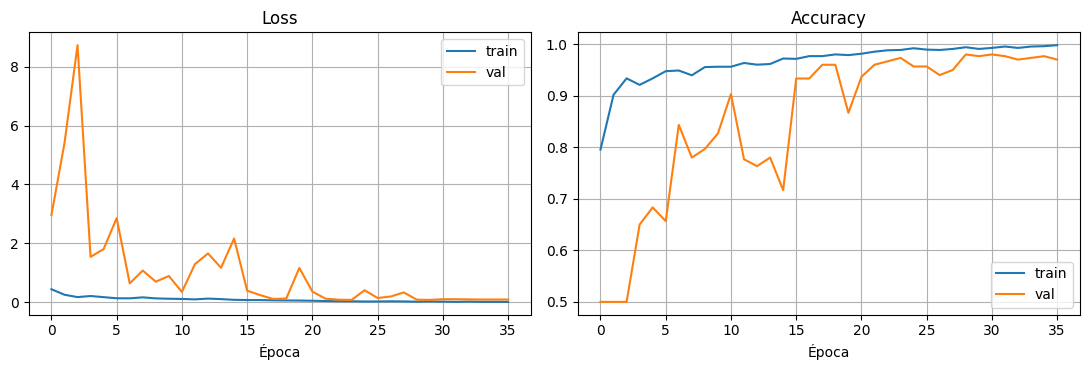

In [9]:
# ===============================
# ENTRENAMIENTO DEL MODELO
# ===============================

class_weight = {0: 1.0, 1: 1.0}   # pesos iguales para ambas clases

historial = modeloCNN.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[tensorboardCNN, early_stop, reduce_lr],
    class_weight=class_weight
)

# Curvas de aprendizaje
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(historial.history["loss"], label="train"); ax[0].plot(historial.history["val_loss"], label="val"); ax[0].set_title("Loss")
ax[1].plot(historial.history["accuracy"], label="train"); ax[1].plot(historial.history["val_accuracy"], label="val"); ax[1].set_title("Accuracy")
for a in ax:
    a.set_xlabel("Época"); a.grid(); a.legend()
plt.tight_layout(); plt.show()

In [10]:
# ===============================
# EVALUACIÓN COMPLETA - TRAIN, VALIDATION Y TEST
# ===============================

UMBRAL = 0.5   # umbral de decisión

def evaluar_conjunto(modelo, X_, y_, umbral=UMBRAL):
    prob = modelo.predict(X_, verbose=0).ravel()
    pred = (prob > umbral).astype(int)
    return {
        "acc":  accuracy_score(y_, pred),
        "prec": precision_score(y_, pred, zero_division=0),
        "rec":  recall_score(y_, pred, zero_division=0),
        "f1":   f1_score(y_, pred, zero_division=0),
        "cm":   confusion_matrix(y_, pred, labels=[0, 1]),
        "prob": prob,
    }

print("\n" + "="*80)
print("EVALUANDO MODELO EN LOS 3 CONJUNTOS")
print("="*80)

loss_train, *_ = modeloCNN.evaluate(X_train, y_train, verbose=0)
loss_val,   *_ = modeloCNN.evaluate(X_val,   y_val,   verbose=0)
loss_test,  *_ = modeloCNN.evaluate(X_test,  y_test,  verbose=0)

r_train = evaluar_conjunto(modeloCNN, X_train, y_train)
r_val   = evaluar_conjunto(modeloCNN, X_val,   y_val)
r_test  = evaluar_conjunto(modeloCNN, X_test,  y_test)

# -------- MATRICES DE CONFUSIÓN --------
print("\nMATRICES DE CONFUSIÓN:")
print("-" * 80)
for nombre, r in [("TRAIN", r_train), ("VALIDATION", r_val), ("TEST", r_test)]:
    cm = r["cm"]
    print(f"{nombre}:")
    print(cm)
    print(f"  TN={cm[0,0]} | FP={cm[0,1]}")
    print(f"  FN={cm[1,0]} | TP={cm[1,1]}\n")

# -------- RESUMEN DE MÉTRICAS --------
print("="*80)
print("RESUMEN DE MÉTRICAS")
print("="*80)
print(f"{'Conjunto':<12} | {'Loss':<8} | {'Accuracy':<8} | {'Precision':<9} | {'Recall':<8} | {'F1-score':<8}")
print("-" * 80)
for nombre, loss, r in [("TRAIN", loss_train, r_train), ("VALIDATION", loss_val, r_val), ("TEST", loss_test, r_test)]:
    print(f"{nombre:<12} | {loss:<8.4f} | {r['acc']:<8.4f} | {r['prec']:<9.4f} | {r['rec']:<8.4f} | {r['f1']:<8.4f}")
print("="*80)

print("\nREPORTE DE CLASIFICACIÓN (TEST):")
print(classification_report(y_test, (r_test["prob"] > UMBRAL).astype(int),
                            target_names=["No barco", "Barco"], digits=4))

# -------- ANÁLISIS DE GENERALIZACIÓN --------
print("="*80)
print("ANÁLISIS DE GENERALIZACIÓN")
print("="*80)

diff_train_val  = abs(r_train["acc"] - r_val["acc"])
diff_val_test   = abs(r_val["acc"] - r_test["acc"])
diff_train_test = abs(r_train["acc"] - r_test["acc"])

print(f"Diferencia Train-Validation:  {diff_train_val:.4f} ({diff_train_val*100:.2f}%)")
print(f"Diferencia Validation-Test:   {diff_val_test:.4f} ({diff_val_test*100:.2f}%)")
print(f"Diferencia Train-Test:        {diff_train_test:.4f} ({diff_train_test*100:.2f}%)")

if diff_val_test < 0.03:
    print("\n EXCELENTE: Validation y Test muy similares (< 3% diferencia)")
    print("   → El modelo generaliza correctamente")
elif diff_val_test < 0.05:
    print("\n BUENO: Validation y Test razonablemente similares (< 5% diferencia)")
    print("   → El modelo generaliza bien")
else:
    print("\n ADVERTENCIA: Diferencia significativa entre Validation y Test (> 5%)")
    print("   → Posible overfitting o validation set no representativo")

# -------- ANÁLISIS DE ERRORES --------
cm_test = r_test["cm"]
print("\n" + "="*80)
print("ANÁLISIS DE ERRORES EN TEST")
print("="*80)
print(f"Falsos negativos (barcos NO detectados): {cm_test[1,0]}/{int(np.sum(y_test == 1))}")
print(f"Falsos positivos (agua/tierra marcada como barco): {cm_test[0,1]}/{int(np.sum(y_test == 0))}")

# -------- META DEL ENUNCIADO (> 98% accuracy en test) --------
acc_pct = r_test["acc"] * 100
print("\n" + "="*80)
print(f"ACCURACY TEST: {acc_pct:.2f}%  (meta del enunciado: > 98%)")
if acc_pct >= 98:
    print(" META CUMPLIDA")
else:
    print(f" Por debajo de la meta. Penalización estimada: -{((98 - acc_pct) / 2) * 0.5:.2f} puntos (0.5 por cada 2% bajo 98%)")
print("="*80)


EVALUANDO MODELO EN LOS 3 CONJUNTOS

MATRICES DE CONFUSIÓN:
--------------------------------------------------------------------------------
TRAIN:
[[741  12]
 [  7 746]]
  TN=741 | FP=12
  FN=7 | TP=746

VALIDATION:
[[144   6]
 [  2 148]]
  TN=144 | FP=6
  FN=2 | TP=148

TEST:
[[ 97   3]
 [  0 100]]
  TN=97 | FP=3
  FN=0 | TP=100

RESUMEN DE MÉTRICAS
Conjunto     | Loss     | Accuracy | Precision | Recall   | F1-score
--------------------------------------------------------------------------------
TRAIN        | 0.0354   | 0.9874   | 0.9842    | 0.9907   | 0.9874  
VALIDATION   | 0.0798   | 0.9733   | 0.9610    | 0.9867   | 0.9737  
TEST         | 0.0374   | 0.9850   | 0.9709    | 1.0000   | 0.9852  

REPORTE DE CLASIFICACIÓN (TEST):
              precision    recall  f1-score   support

    No barco     1.0000    0.9700    0.9848       100
       Barco     0.9709    1.0000    0.9852       100

    accuracy                         0.9850       200
   macro avg     0.9854    0.9850   

AUC: 0.9992


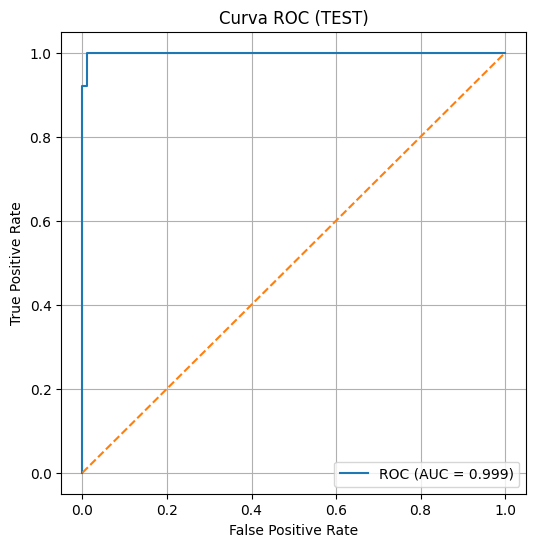

In [11]:
# ===============================
# CURVA ROC Y AUC (TEST)
# ===============================

fpr, tpr, thresholds = roc_curve(y_test, r_test["prob"])
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (TEST)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [12]:
# ===============================
# GUARDAR MODELO EN GOOGLE DRIVE Y DESCARGAR
# ===============================

CARPETA_SALIDA = "/content/drive/MyDrive/DataSet_Split/modelo_barcos_cnn"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

ruta_modelo = os.path.join(CARPETA_SALIDA, "modelo_barcos_cnn.keras")
modeloCNN.save(ruta_modelo)

config = {
    "tamano_entrada": [80, 80, 3],
    "canales": "RGB",
    "rango_entrada": "float32 0-255 sin normalizar (el modelo normaliza internamente)",
    "umbral": UMBRAL,
    "clases": {"0": "No_Barcos", "1": "Barcos"},
    "salida": "probabilidad de barco (sigmoid)",
    "tensorflow": tf.__version__,
    "accuracy_test": float(r_test["acc"]),
}
with open(os.path.join(CARPETA_SALIDA, "config_modelo_cnn.json"), "w") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Verificación: recargar y comprobar que predice igual
modelo_recargado = tf.keras.models.load_model(ruta_modelo)
diff = np.abs(modelo_recargado.predict(X_test[:50], verbose=0) - modeloCNN.predict(X_test[:50], verbose=0)).max()
print("Modelo guardado correctamente en:", ruta_modelo)
print(f"Diferencia máxima tras recargar: {diff:.2e}  (debe ser ~0)")

files.download(ruta_modelo)
files.download(os.path.join(CARPETA_SALIDA, "config_modelo_cnn.json"))

Modelo guardado correctamente en: /content/drive/MyDrive/DataSet_Split/modelo_barcos_cnn/modelo_barcos_cnn.keras
Diferencia máxima tras recargar: 0.00e+00  (debe ser ~0)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cargando: 100%|██████████| 40/40 [00:30<00:00,  1.32it/s]



Imágenes cargadas: 40 | con etiqueta: True

EVALUACIÓN CON IMÁGENES NUEVAS
Imágenes: 40 (barcos: 24 | no barcos: 16)
Accuracy : 0.9250 (92.50%)
Precision: 0.9565
Recall   : 0.9167
F1-score : 0.9362

Matriz de confusión:
[[15  1]
 [ 2 22]]
  TN=15 | FP=1
  FN=2 | TP=22

              precision    recall  f1-score   support

    No barco     0.8824    0.9375    0.9091        16
       Barco     0.9565    0.9167    0.9362        24

    accuracy                         0.9250        40
   macro avg     0.9194    0.9271    0.9226        40
weighted avg     0.9269    0.9250    0.9253        40

AUC: 0.9427


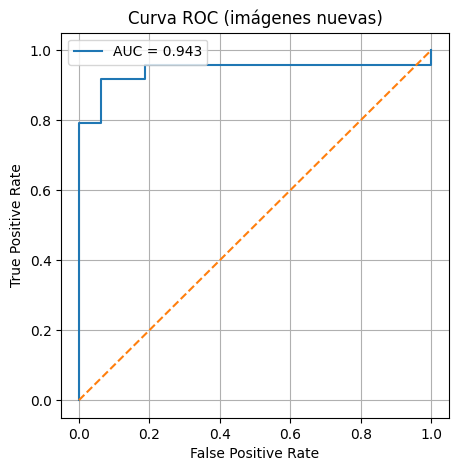


Meta del enunciado: > 98% | Resultado: 92.50%
 Penalización estimada: -1.38 puntos


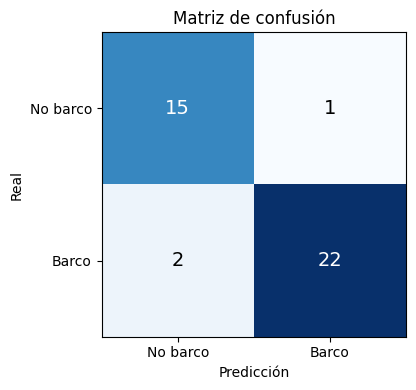


Imágenes mal clasificadas: 3


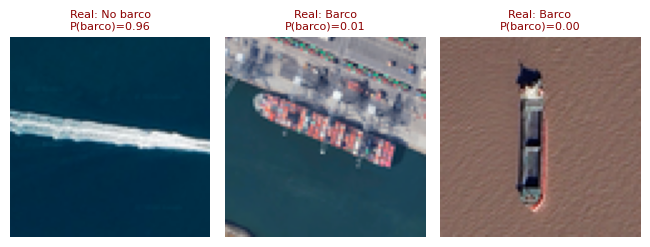


Probabilidades de las imágenes mal clasificadas:
  img19.png -> P(barco) = 0.9612
  img10.png -> P(barco) = 0.0064
  img25.png -> P(barco) = 0.0000

Barrido de umbral:
  umbral 0.5: acc=0.9250 | FP=1 | FN=2
  umbral 0.4: acc=0.9250 | FP=1 | FN=2
  umbral 0.3: acc=0.9000 | FP=2 | FN=2
  umbral 0.2: acc=0.9000 | FP=2 | FN=2
  umbral 0.1: acc=0.9000 | FP=2 | FN=2

Predicciones guardadas en: /content/drive/MyDrive/DataSet_Split/modelo_barcos_cnn/predicciones_imagenes_nuevas_cnn.csv


,archivo,prob_barco,prediccion,real,correcto
0,img11.png,0.0000,No barco,No barco,True
1,img19.png,0.9612,Barco,No barco,False
2,img2.png,0.0000,No barco,No barco,True
3,img33.png,0.0000,No barco,No barco,True
4,img34.png,0.0000,No barco,No barco,True
5,img35.png,0.0000,No barco,No barco,True
6,img36.png,0.0002,No barco,No barco,True
7,img37.png,0.0000,No barco,No barco,True
8,img38.png,0.0040,No barco,No barco,True
9,img39.png,0.0000,No barco,No barco,True


In [13]:
# ===============================
# EVALUACIÓN CON IMÁGENES NUEVAS (desde Drive)
# ===============================
# Evalúa con imágenes que NUNCA vio. La carpeta puede tener:
#   A) subcarpetas  Barcos/  y  No_Barcos/        (la etiqueta sale de la carpeta), o
#   B) una carpeta plana con nombres tipo "1__xxx.png" (barco) y "0__xxx.png" (no barco).

RUTA_PRUEBA = "/content/drive/MyDrive/DataSetv2"   # <-- CAMBIAR por tu carpeta
USAR_MODELO_GUARDADO = False                            # True = recarga el .keras guardado en Drive

if USAR_MODELO_GUARDADO:
    modelo_eval = tf.keras.models.load_model("/content/drive/MyDrive/DataSet_Split/modelo_barcos_cnn/modelo_barcos_cnn.keras")
else:
    modelo_eval = modeloCNN

# ---- 1) Listar imágenes y etiquetas ----
items = []   # (ruta, etiqueta o None)
if all(os.path.isdir(os.path.join(RUTA_PRUEBA, c)) for c in CLASES):
    for clase in CLASES:
        et = 1 if clase == "Barcos" else 0
        for f in sorted(os.listdir(os.path.join(RUTA_PRUEBA, clase))):
            if f.lower().endswith(EXT_VALIDAS):
                items.append((os.path.join(RUTA_PRUEBA, clase, f), et))
else:
    for f in sorted(os.listdir(RUTA_PRUEBA)):
        if f.lower().endswith(EXT_VALIDAS):
            et = 1 if f.startswith("1__") else (0 if f.startswith("0__") else None)
            items.append((os.path.join(RUTA_PRUEBA, f), et))

# ---- 2) Cargar con el MISMO preprocesamiento del entrenamiento ----
X_new, y_new, nombres = [], [], []
for ruta, et in tqdm(items, desc="Cargando"):
    img, _ = cargar_imagen(ruta)
    if img is None:
        continue
    X_new.append(img); y_new.append(-1 if et is None else et); nombres.append(os.path.basename(ruta))

X_new = np.array(X_new, dtype="float32")
y_new = np.array(y_new)
con_etiqueta = bool(len(y_new)) and np.all(y_new >= 0)
print(f"\nImágenes cargadas: {len(X_new)} | con etiqueta: {con_etiqueta}")

# ---- 3) Predicción ----
prob_new = modelo_eval.predict(X_new, verbose=0).ravel()
pred_new = (prob_new > UMBRAL).astype(int)

# ---- 4) Indicadores ----
if con_etiqueta:
    acc  = accuracy_score(y_new, pred_new)
    prec = precision_score(y_new, pred_new, zero_division=0)
    rec  = recall_score(y_new, pred_new, zero_division=0)
    f1   = f1_score(y_new, pred_new, zero_division=0)
    cm   = confusion_matrix(y_new, pred_new, labels=[0, 1])

    print("\n" + "="*80)
    print("EVALUACIÓN CON IMÁGENES NUEVAS")
    print("="*80)
    print(f"Imágenes: {len(y_new)} (barcos: {int(y_new.sum())} | no barcos: {int((y_new == 0).sum())})")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nMatriz de confusión:")
    print(cm)
    print(f"  TN={cm[0,0]} | FP={cm[0,1]}")
    print(f"  FN={cm[1,0]} | TP={cm[1,1]}")
    print("\n" + classification_report(y_new, pred_new, labels=[0, 1],
                                       target_names=["No barco", "Barco"], digits=4, zero_division=0))

    if len(np.unique(y_new)) == 2:
        fpr_n, tpr_n, _ = roc_curve(y_new, prob_new)
        auc_n = auc(fpr_n, tpr_n)
        print(f"AUC: {auc_n:.4f}")
        plt.figure(figsize=(5, 5))
        plt.plot(fpr_n, tpr_n, label=f"AUC = {auc_n:.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title("Curva ROC (imágenes nuevas)"); plt.legend(); plt.grid(True); plt.show()

    acc_pct = acc * 100
    print(f"\nMeta del enunciado: > 98% | Resultado: {acc_pct:.2f}%")
    if acc_pct >= 98:
        print(" META CUMPLIDA")
    else:
        print(f" Penalización estimada: -{((98 - acc_pct) / 2) * 0.5:.2f} puntos")

    # Matriz de confusión gráfica
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No barco", "Barco"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No barco", "Barco"])
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout(); plt.show()

    # Imágenes mal clasificadas
    errores = np.where(pred_new != y_new)[0]
    print(f"\nImágenes mal clasificadas: {len(errores)}")
    if len(errores):
        mostrar = errores[:12]
        fig, axes = plt.subplots(1, len(mostrar), figsize=(2.2*len(mostrar), 2.8), squeeze=False)
        for ax, i in zip(axes[0], mostrar):
            ax.imshow(X_new[i].astype("uint8")); ax.axis("off")
            real = "Barco" if y_new[i] == 1 else "No barco"
            ax.set_title(f"Real: {real}\nP(barco)={prob_new[i]:.2f}", fontsize=8, color="#8B0000")
        plt.tight_layout(); plt.show()

        print("\nProbabilidades de las imágenes mal clasificadas:")
        for i in errores:
            print(f"  {nombres[i]} -> P(barco) = {prob_new[i]:.4f}")

    # Barrido de umbral (solo diagnóstico; no ajustes el umbral con pocas imágenes)
    print("\nBarrido de umbral:")
    for u in [0.5, 0.4, 0.3, 0.2, 0.1]:
        p = (prob_new > u).astype(int)
        print(f"  umbral {u}: acc={accuracy_score(y_new, p):.4f} | "
              f"FP={int(((p == 1) & (y_new == 0)).sum())} | FN={int(((p == 0) & (y_new == 1)).sum())}")
else:
    print("\nLas imágenes no tienen etiqueta reconocible: se muestran solo las predicciones.")

# ---- 5) Tabla de predicciones (se guarda en Drive) ----
tabla = pd.DataFrame({
    "archivo": nombres,
    "prob_barco": np.round(prob_new, 4),
    "prediccion": np.where(pred_new == 1, "Barco", "No barco"),
})
if con_etiqueta:
    tabla["real"] = np.where(y_new == 1, "Barco", "No barco")
    tabla["correcto"] = tabla["prediccion"] == tabla["real"]

os.makedirs(CARPETA_SALIDA, exist_ok=True)
ruta_csv = os.path.join(CARPETA_SALIDA, "predicciones_imagenes_nuevas_cnn.csv")
tabla.to_csv(ruta_csv, index=False)
print(f"\nPredicciones guardadas en: {ruta_csv}")
tabla.head(20)

In [ ]:
# ===============================
# TENSORBOARD
# ===============================
%load_ext tensorboard
%tensorboard --logdir logs